In [35]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('overall_model_compare.csv')

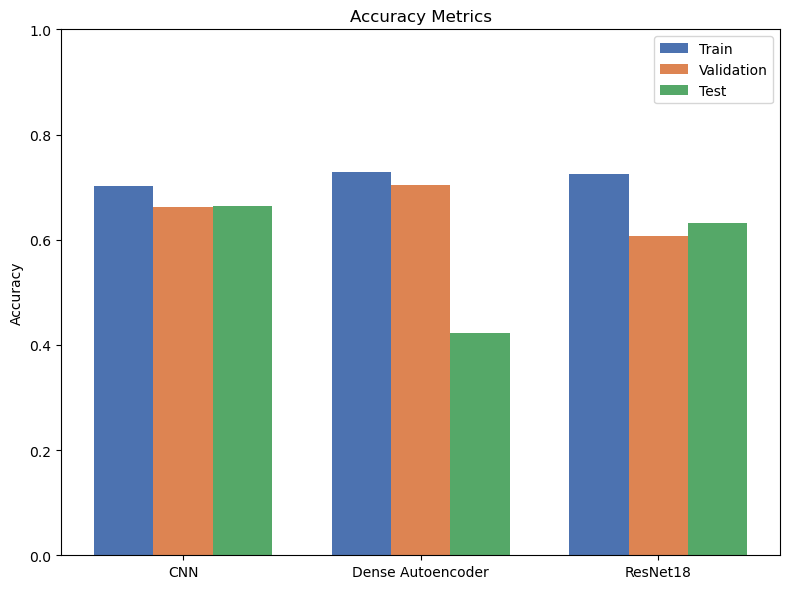

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data with tab separator
df = pd.read_csv('overall_model_compare.csv', sep='\t')

# 2. Automatically flip (transpose) the table if models are columns
if any('CNN' in str(c) for c in df.columns):
    df.set_index(df.columns[0], inplace=True)
    df = df.T
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Model'}, inplace=True)

# 3. Clean up formatting
df.columns = df.columns.str.strip()
df['Model'] = df['Model'].apply(lambda x: 'Dense Autoencoder' if 'Autoencoder' in str(x) else str(x))

# 4. Convert all metrics to numbers
for col in df.columns:
    if col != 'Model':
        df[col] = pd.to_numeric(df[col], errors='coerce')

x = np.arange(len(df['Model']))
width = 0.25

# ==========================================
# Graph 1: Accuracy Metrics
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(x - width, df['Training Accuracy'], width, label='Train', color='#4C72B0')
ax1.bar(x, df['Validation Accuracy'], width, label='Validation', color='#DD8452')
ax1.bar(x + width, df['Test Accuracy'], width, label='Test', color='#55A868')
ax1.set_title('Accuracy Metrics')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Model'])
ax1.legend()
ax1.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('accuracy_metrics_only.png')
plt.show()


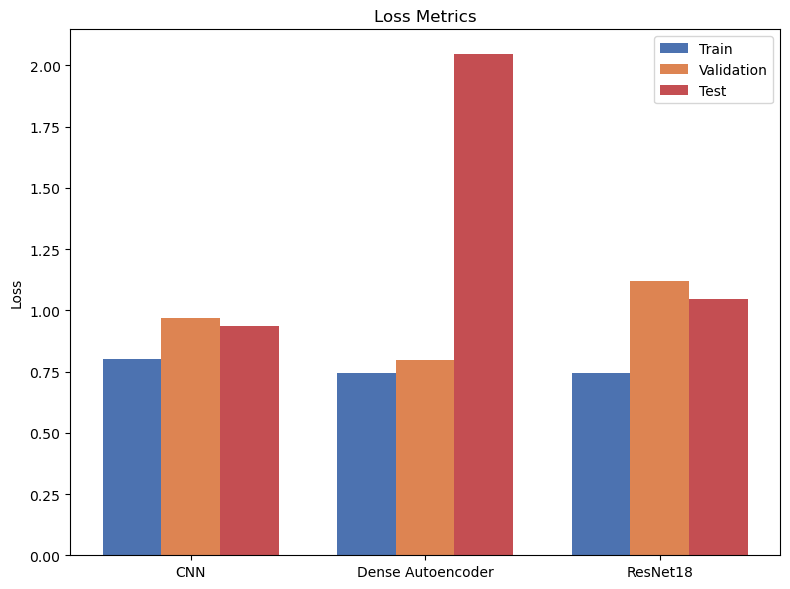

In [38]:

# ==========================================
# Graph 2: Loss Metrics
# ==========================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.bar(x - width, df['Training Loss'], width, label='Train', color='#4C72B0')
ax2.bar(x, df['Validation Loss'], width, label='Validation', color='#DD8452')
ax2.bar(x + width, df['Test Loss'], width, label='Test', color='#C44E52')
ax2.set_title('Loss Metrics')
ax2.set_ylabel('Loss')
ax2.set_xticks(x)
ax2.set_xticklabels(df['Model'])
ax2.legend()

plt.tight_layout()
plt.savefig('loss_metrics_only.png')
plt.show()


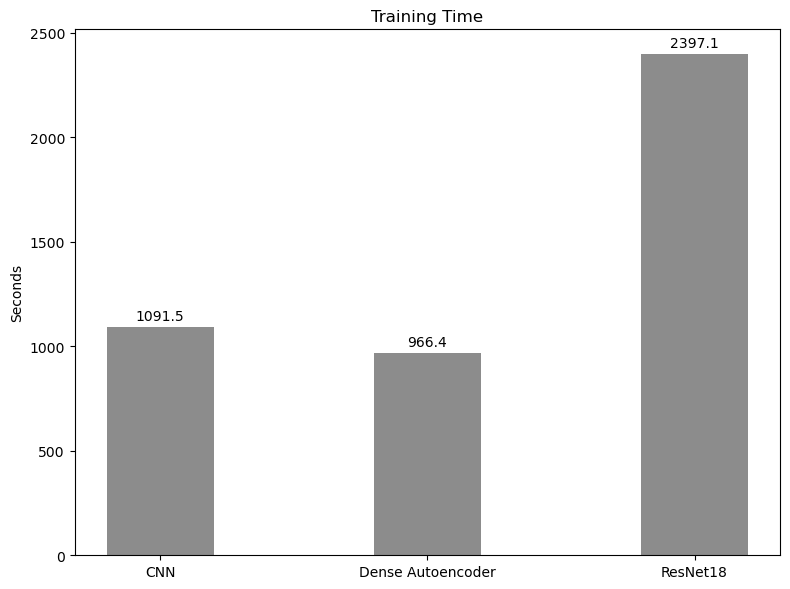

In [39]:

# ==========================================
# Graph 3: Training Time
# ==========================================
time_col = [col for col in df.columns if 'time' in col.lower()][0]

fig3, ax3 = plt.subplots(figsize=(8, 6))
bars = ax3.bar(x, df[time_col], color='#8C8C8C', width=0.4)
ax3.set_title('Training Time')
ax3.set_ylabel('Seconds')
ax3.set_xticks(x)
ax3.set_xticklabels(df['Model'])
ax3.bar_label(bars, padding=3, fmt='%.1f')

plt.tight_layout()
plt.savefig('training_time_only.png')
plt.show()